In [1]:
# importing packages and modules
import numpy as np
import matplotlib as mpl
import scipy.stats as stats
from scipy.optimize import minimize, check_grad
from io_utils import *
from utils import *
from plotting_utils import *
from analysis_utils import *
import dynamic_glmhmm
from scipy.stats import multivariate_normal, norm
sns.set_context("talk")

colormap = ['tab:purple','tab:pink','tab:cyan','yellowgreen', 'olive']
colorsStates = ['tab:orange','tab:blue','tab:green','tab:purple', 'tab:brown']
myFeatures = [['bias','stimulus', 'previous choice', 'previous reward'],['bias','contrast left','contrast right', 'previous choice', 'previous reward']]
ibl_data_path = '../data_IBL'
# dfAll = pd.read_csv(ibl_data_path + '/Ibl_processed.csv')
dfAll = pd.read_csv(ibl_data_path + '/IBL_processed_extra.csv')

labChosen =  ['angelakilab','churchlandlab','wittenlab']
subjectsAll = []
for lab in labChosen:
    subjects = np.unique(dfAll[dfAll['lab'] == lab]['subject']).tolist()
    subjectsAll = subjectsAll + subjects

# missing data
if ('NYU-01' in subjectsAll):
    subjectsAll.remove('NYU-01')
if ('NYU-06' in subjectsAll):
    subjectsAll.remove('NYU-06')
if ('CSHL_007' in subjectsAll):
    subjectsAll.remove('CSHL_007')
if ('CSHL049' in subjectsAll):
    subjectsAll.remove('CSHL049')
if ('CSHL024' in subjectsAll):
    subjectsAll.remove('CSHL024')

In [2]:
dfAll.head()

,contrastLeft,contrastRight,choice,feedbackType,probabilityLeft,lab,subject,date,session,correctSide,response_times,RT
0,1.0,0.0,1.0,0.0,1.0,angelakilab,IBL-T1,2019-02-09,1.0,0.0,NaN,NaN
1,1.0,0.0,1.0,0.0,1.0,angelakilab,IBL-T1,2019-02-09,1.0,0.0,NaN,NaN
2,0.0,1.0,1.0,1.0,1.0,angelakilab,IBL-T1,2019-02-09,1.0,1.0,NaN,NaN
3,0.5,0.0,0.0,1.0,0.5,angelakilab,IBL-T1,2019-02-09,1.0,0.0,NaN,NaN
4,0.5,0.0,0.0,1.0,0.9,angelakilab,IBL-T1,2019-02-09,1.0,0.0,NaN,NaN


In [7]:
# from one.api import ONE
# ONE.setup(base_url='https://openalyx.internationalbrainlab.org', silent=True)
# ONE.cache_clear()
# one = ONE(password='international')
# # 'left', 'right' or 'body'
# for subject in subjectsAll:
#     try:
#         eids, infos = one.search(details=True, subject=subject) #, task_protocol='training')
#         video_features = one.load_object(eids[0], f'bodyCamera', collection='alf')
#         print(video_features)
#     except Exception as e:
#         print(f'Error loading trials for {eid}: {e}')

In [8]:
# from one.api import ONE
# ONE.setup(base_url='https://openalyx.internationalbrainlab.org', silent=True)
# ONE.cache_clear()
# one = ONE(password='international')

Connected to https://openalyx.internationalbrainlab.org as user "intbrainlab"


In [9]:
# def load_object_if_exists(eid, obj, collection='alf', attributes=None):
#     # ALF files for an object are typically named like: _ibl_<object>.<attribute>.<ext>
#     # e.g. _ibl_rightCamera.times.npy, _ibl_rightCamera.dlc.pqt
#     prefix = f"_ibl_{obj}."
#     dsets = one.list_datasets(eid, collection=collection, filename=prefix + "*")
#     if not dsets:
#         return None

#     if attributes is None:
#         return one.load_object(eid, obj, collection=collection)
#     else:
#         return one.load_object(eid, obj, collection=collection, attribute=attributes)

# eid = '4ecb5d24-f5cc-402c-be28-9d0f7cb14b3a'
# cam = load_object_if_exists(eid, 'rightCamera', collection='alf', attributes=['times', 'dlc'])
# trial_data = one.load_object(eid, 'trials')
# print("cam is None?", cam is None)
# if cam is not None:
#     print("Loaded keys:", cam.keys())

/Users/lencacuturela/opt/anaconda3/envs/dglmhmm/lib/python3.10/site-packages/one/util.py:436: ALFWarning: Multiple revisions: "2022-01-31", ""
  warnings.warn(f'Multiple revisions: {rev_list}', alferr.ALFWarning)
/Users/lencacuturela/opt/anaconda3/envs/dglmhmm/lib/python3.10/site-packages/one/util.py:436: ALFWarning: Multiple revisions: "", "2025-03-03"
  warnings.warn(f'Multiple revisions: {rev_list}', alferr.ALFWarning)


cam is None? False
Loaded keys: dict_keys(['dlc', 'times'])


In [12]:
# def load_IBL_behavioral_data():
#     '''
#     Load data from IBL database for a given protocol, into a pandas dataframe.
#     Select the `trainable` the subjects that moved to biasedChoiceWorld, thus attained status `Trained 1b`. 
#     Args:
#         protocol: str, the protocol to load data from. Select from ['training', 'no_curriculum', 'training_biasedChoiceWorld']
#     returns: 
#         entries: pd.DataFrame, the data from the IBL database, with columns:
#             ['lab', 'subject', 'date', 'contrastRight', 'choice', 'probabilityLeft', 'feedbackType', 'rewardVolume', 'contrastLeft']
#     '''
#     from one.api import ONE
#     ONE.setup(base_url='https://openalyx.internationalbrainlab.org', silent=True)
#     ONE.cache_clear()
#     one = ONE(password='international')
#     # eids, infos = one.search(details=True, subject=subject) #, task_protocol='training')

#     # eids, infos = one.search(subject='ibl_witten_12', details=True)

#     eids, infos = one.search(details=True, lab='churchlandlab')
#     # eid = '4ecb5d24-f5cc-402c-be28-9d0f7cb14b3a'

#     # dfsub = dfAll[dfAll['subject']==subject]

#     # Select keys for trial data that are not time dependent (e.g. 'goCue_times')
#     keys = ['contrastLeft', 'contrastRight', 'choice', 'probabilityLeft', 'feedbackType', 'rewardVolume']
#     keys_dlc = ['pupil_top_r_x',
#        'pupil_top_r_y', 'pupil_top_r_likelihood', 'pupil_right_r_x',
#        'pupil_right_r_y', 'pupil_right_r_likelihood', 'pupil_bottom_r_x',
#        'pupil_bottom_r_y', 'pupil_bottom_r_likelihood', 'pupil_left_r_x',
#        'pupil_left_r_y', 'pupil_left_r_likelihood']

#     def check_keys(trial_data) -> bool:
#         return np.all([key in trial_data.keys() for key in keys])

#     # Compile data into a pandas dataframe
#     entries = {'lab': [], 'subject': [], 'date': [], 'session': []}
#     for key in keys:
#         entries[key] = []
#     entries['pupil_mean1'] = []
#     entries['pupil_mean2'] = []
#     entries['RT'] = []
   

#     error_animals = []
#     for eid, info in zip(eids, infos):
#         print(eid, info)
#         cam = load_object_if_exists(eid, 'rightCamera', collection='alf', attributes=['times', 'dlc'])
#         if cam is not None:
#             try:
                
#                 # trial_data = one.load_object(eid) #, 'trials')
#                 trial_data = one.load_object(eid, 'trials')
#                 assert check_keys(trial_data), f'Keys missing.'
             

#                 # print("rows:", len(idx), "trial_data:", len(rt))
                    
#                 for t in range(len(trial_data['choice'])):
#                     # entries['lab'].append('lab')
#                     # entries['subject'].append('subject')
#                     # entries['date'].append(str('date'))
#                     # entries['session'].append('number')
#                     entries['lab'].append(info['lab'])
#                     entries['subject'].append(info['subject'])
#                     entries['date'].append(str(info['date']))
#                     entries['session'].append(info['number'])

#                     idx1 = (cam['times'] > trial_data['intervals'][t][0]) & (cam['times'] < trial_data['intervals'][t][1]) 
#                     idx2 = (cam['times'] > trial_data['stimOn_times'][t]) & (cam['times'] < trial_data['response_times'][t])
#                     # idx3 = (cam['times'] > trial_data['stimOn_times'][t]) & (cam['times'] < trial_data['stimOff_times'])

#                     # trial info 
#                     for key in keys:
#                         entries[key].append(float(trial_data[key][t]))

#                     try:
#                         entries['RT'].append(trial_data['response_times'][t] - trial_data['goCue_times'][t])
#                     except Exception:
#                         entries['RT'].append(np.nan)

#                     try:
#                         idx1 = (cam['times'] > trial_data['intervals'][t][0]) & (cam['times'] < trial_data['intervals'][t][1])
#                         idx2 = (cam['times'] > trial_data['stimOn_times'][t]) & (cam['times'] < trial_data['response_times'][t])

#                         good_height = (cam['dlc']['pupil_top_r_likelihood'] > 0.7) & (cam['dlc']['pupil_bottom_r_likelihood'] > 0.7)
#                         good_width  = (cam['dlc']['pupil_right_r_likelihood'] > 0.7) & (cam['dlc']['pupil_left_r_likelihood'] > 0.7)

#                         pupil_height1 = np.nanmean(np.linalg.norm(
#                             np.array(cam['dlc'].loc[idx1 & good_height][['pupil_top_r_x','pupil_top_r_y']]) -
#                             np.array(cam['dlc'].loc[idx1 & good_height][['pupil_bottom_r_x','pupil_bottom_r_y']]),
#                             axis=1
#                         ))
#                         pupil_width1 = np.nanmean(np.linalg.norm(
#                             np.array(cam['dlc'].loc[idx1 & good_width][['pupil_right_r_x','pupil_right_r_y']]) -
#                             np.array(cam['dlc'].loc[idx1 & good_width][['pupil_left_r_x','pupil_left_r_y']]),
#                             axis=1
#                         ))
#                         pupil_height2 = np.nanmean(np.linalg.norm(
#                             np.array(cam['dlc'].loc[idx2 & good_height][['pupil_top_r_x','pupil_top_r_y']]) -
#                             np.array(cam['dlc'].loc[idx2 & good_height][['pupil_bottom_r_x','pupil_bottom_r_y']]),
#                             axis=1
#                         ))
#                         pupil_width2 = np.nanmean(np.linalg.norm(
#                             np.array(cam['dlc'].loc[idx2 & good_width][['pupil_right_r_x','pupil_right_r_y']]) -
#                             np.array(cam['dlc'].loc[idx2 & good_width][['pupil_left_r_x','pupil_left_r_y']]),
#                             axis=1
#                         ))

#                         entries['pupil_mean1'].append(np.nanmean(np.array([pupil_height1, pupil_width1])))
#                         entries['pupil_mean2'].append(np.nanmean(np.array([pupil_height2, pupil_width2])))

#                     except Exception:
#                         # critical: keep lengths aligned
#                         entries['pupil_mean1'].append(np.nan)
#                         entries['pupil_mean2'].append(np.nan)
                    
#                     # entries['RT'].append(trial_data['response_times'][t]-trial_data['goCue_times'][t])
                    
#                     # # masking low likelihood frames
#                     # good_height = (cam['dlc']['pupil_top_r_likelihood'] > 0.7) & (cam['dlc']['pupil_bottom_r_likelihood'] > 0.7)
#                     # good_width = (cam['dlc']['pupil_right_r_likelihood'] > 0.7) & (cam['dlc']['pupil_left_r_likelihood'] > 0.7)
                    
#                     # pupil_height1 = np.nanmean(np.linalg.norm(np.array(cam['dlc'].loc[idx1 & good_height][['pupil_top_r_x','pupil_top_r_y']]) - np.array(cam['dlc'].loc[idx1 & good_height][['pupil_bottom_r_x','pupil_bottom_r_y']]), axis=1))
#                     # pupil_width1 = np.nanmean(np.linalg.norm(np.array(cam['dlc'].loc[idx1 & good_width][['pupil_right_r_x','pupil_right_r_y']]) - np.array(cam['dlc'].loc[idx1 & good_width][['pupil_left_r_x','pupil_left_r_y']]), axis=1))
#                     # # print(pupil_height1)
#                     # # print(pupil_width1)
#                     # pupil_height2 = np.nanmean(np.linalg.norm(np.array(cam['dlc'].loc[idx2 & good_height][['pupil_top_r_x','pupil_top_r_y']]) - np.array(cam['dlc'].loc[idx2 & good_height][['pupil_bottom_r_x','pupil_bottom_r_y']]), axis=1))
#                     # pupil_width2 = np.nanmean(np.linalg.norm(np.array(cam['dlc'].loc[idx2 & good_width][['pupil_right_r_x','pupil_right_r_y']]) - np.array(cam['dlc'].loc[idx2 & good_width][['pupil_left_r_x','pupil_left_r_y']]), axis=1))

#                     # entries['pupil_mean1'].append(np.nanmean(np.array([pupil_height1,pupil_width1])))
#                     # entries['pupil_mean2'].append(np.nanmean(np.array([pupil_height2,pupil_width2])))
        
#             except Exception as e: # Catch any errors, leave out the data
#                 print(f'Error loading trials for {eid}: {e}')
#                 # error_animals.append(info['subject'])
#                 continue

#     for k, v in entries.items():
#         print(k, len(v))

#     entries_df = pd.DataFrame(entries)
#     # entries_df = entries_df.fillna(0) # NaNs are on the contrast information, which is 0 when not present
    
#     return entries_df # , error_animals
# entries_df = load_IBL_behavioral_data()
# # for subject in subjectsAll[:]:
# #     entries_df, error_animals =  load_IBL_behavioral_data()

Connected to https://openalyx.internationalbrainlab.org as user "intbrainlab"
f45e30cf-12aa-4fa0-8248-f9f885dfa9ef {'id': 'f45e30cf-12aa-4fa0-8248-f9f885dfa9ef', 'subject': 'CSHL075', 'start_time': '2020-10-15T09:01:07', 'number': 4, 'lab': 'churchlandlab', 'projects': ['churchland_learninglifespan'], 'url': 'https://openalyx.internationalbrainlab.org/sessions/f45e30cf-12aa-4fa0-8248-f9f885dfa9ef', 'task_protocol': '_iblrig_tasks_ephysChoiceWorld6.4.2', 'date': datetime.date(2020, 10, 15)}


KeyboardInterrupt: 

In [13]:
# entries_df.head()
# entries_df.to_csv('IBL_processed_new_batch_churchland.csv', index=False)

dfIBL_churchland = pd.read_csv(ibl_data_path + '/IBL_processed_new_batch_churchland.csv')
dfIBL_churchland.head()


,lab,subject,date,session,contrastLeft,contrastRight,choice,probabilityLeft,feedbackType,rewardVolume,pupil_mean1,pupil_mean2,RT
0,churchlandlab,CSHL075,2020-10-15,4,1.00,NaN,1.0,0.5,1.0,1.5,10.816400,10.687351,0.272443
1,churchlandlab,CSHL075,2020-10-15,4,NaN,0.125,-1.0,0.5,1.0,1.5,10.425780,10.237078,2.133587
2,churchlandlab,CSHL075,2020-10-15,4,0.25,NaN,-1.0,0.5,-1.0,0.0,10.290754,10.185414,5.068065
3,churchlandlab,CSHL075,2020-10-15,4,NaN,1.000,-1.0,0.5,1.0,1.5,9.704977,7.278451,0.251100
4,churchlandlab,CSHL075,2020-10-15,4,0.00,NaN,-1.0,0.5,-1.0,0.0,9.776015,10.017833,2.453139


In [11]:
# dfAll['RT'] = np.nan
# def load_IBL_behavioral_data_old(subject):
#     '''
#     Load data from IBL database for a given protocol, into a pandas dataframe.
#     Select the `trainable` the subjects that moved to biasedChoiceWorld, thus attained status `Trained 1b`. 
#     Args:
#         protocol: str, the protocol to load data from. Select from ['training', 'no_curriculum', 'training_biasedChoiceWorld']
#     returns: 
#         entries: pd.DataFrame, the data from the IBL database, with columns:
#             ['lab', 'subject', 'date', 'contrastRight', 'choice', 'probabilityLeft', 'feedbackType', 'rewardVolume', 'contrastLeft']
#     '''
#     from one.api import ONE
#     ONE.setup(base_url='https://openalyx.internationalbrainlab.org', silent=True)
#     ONE.cache_clear()
#     one = ONE(password='international')
#     eids, infos = one.search(details=True, subject=subject) #, task_protocol='training')

#     # eids, infos = one.search(subject='ibl_witten_12', details=True)

#     dfsub = dfAll[dfAll['subject']==subject]

#     # Select keys for trial data that are not time dependent (e.g. 'goCue_times')
#     # keys = ['contrastLeft', 'contrastRight', 'choice', 'probabilityLeft', 'feedbackType', 'rewardVolume', 'response_times']
#     keys = ['response_times', 'goCue_times']
#     def check_keys(trial_data) -> bool:
#         return np.all([key in trial_data.keys() for key in keys])

#     # Compile data into a pandas dataframe
#     entries = {'lab': [], 'subject': [], 'date': [], 'session': []}
#     for key in keys:
#         entries[key] = []

#     error_animals = []
#     for eid, info in zip(eids, infos):
#         try:
            
#             # trial_data = one.load_object(eid) #, 'trials')
#             trial_data = one.load_object(eid, 'trials')
#             assert check_keys(trial_data), f'Keys missing.'


#             mask = (dfAll['subject'] == subject) & (dfAll['date'].astype(str) == str(info['date']))
#             idx = dfAll.index[mask]

#             # rt = np.asarray(trial_data['response_times']-trial_data['goCue_times'], dtype=float)
#             rt = np.asarray(trial_data['response_times']-trial_data['goCue_times'], dtype=float)
#             print("rows:", len(idx), "trial_data:", len(rt))

#             if len(idx) == len(rt):
#                 dfAll.loc[idx, 'RT'] = rt
#             else:
#                 print("Length mismatch, not assigning for", info['subject'], info['date'])
                
#             # for t in range(len(trial_data['choice'])):
#             #     entries['lab'].append(info['lab'])
#             #     entries['subject'].append(info['subject'])
#             #     entries['date'].append(str(info['date']))
#             #     entries['session'].append(info['number'])
                
#             #     for key in keys:
#             #         entries[key].append(float(trial_data[key][t]))
        
#         except Exception as e: # Catch any errors, leave out the data
#             print(f'Error loading trials for {eid}: {e}')
#             error_animals.append(info['subject'])
#             continue

#     entries_df = pd.DataFrame(entries)
#     entries_df = entries_df.fillna(0) # NaNs are on the contrast information, which is 0 when not present
    
#     return entries_df, error_animals

# for subject in subjectsAll[:]:
#     entries_df, error_animals =  load_IBL_behavioral_data_old(subject)

Connected to https://openalyx.internationalbrainlab.org as user "intbrainlab"
rows: 535 trial_data: 535
rows: 693 trial_data: 701
Length mismatch, not assigning for IBL-T1 2019-09-13
rows: 717 trial_data: 718
Length mismatch, not assigning for IBL-T1 2019-09-11
rows: 894 trial_data: 894
rows: 569 trial_data: 569
rows: 374 trial_data: 374
rows: 593 trial_data: 593
rows: 788 trial_data: 788
rows: 844 trial_data: 844
rows: 205 trial_data: 216
Length mismatch, not assigning for IBL-T1 2019-08-19
rows: 478 trial_data: 479
Length mismatch, not assigning for IBL-T1 2019-08-15
rows: 269 trial_data: 274
Length mismatch, not assigning for IBL-T1 2019-08-13
rows: 768 trial_data: 769
Length mismatch, not assigning for IBL-T1 2019-08-09
rows: 273 trial_data: 274
Length mismatch, not assigning for IBL-T1 2019-08-08
rows: 287 trial_data: 296
Length mismatch, not assigning for IBL-T1 2019-08-07
rows: 232 trial_data: 235
Length mismatch, not assigning for IBL-T1 2019-08-06
rows: 399 trial_data: 402
Len

Inconsistent dimensions for object: trials 
(1170,),	repNum
(1073,),	goCue_times
(1073,),	response_times
(1073,),	choice
(1073,),	stimOn_times
(1073,),	contrastLeft
(1073,),	contrastRight
(1073,),	feedback_times
(1073,),	feedbackType
(1073,),	rewardVolume
(1073,),	probabilityLeft
(1073,),	firstMovement_times
(1073, 2),	intervals


rows: 0 trial_data: 1073
Length mismatch, not assigning for NYU-09 2019-12-09
rows: 0 trial_data: 868
Length mismatch, not assigning for NYU-09 2019-12-06
rows: 0 trial_data: 874
Length mismatch, not assigning for NYU-09 2019-12-05
rows: 0 trial_data: 808
Length mismatch, not assigning for NYU-09 2019-12-04
rows: 0 trial_data: 1217
Length mismatch, not assigning for NYU-09 2019-12-03
rows: 0 trial_data: 655
Length mismatch, not assigning for NYU-09 2019-12-02
rows: 352 trial_data: 352
rows: 294 trial_data: 297
Length mismatch, not assigning for NYU-09 2019-11-25
rows: 992 trial_data: 1004
Length mismatch, not assigning for NYU-09 2019-11-22
rows: 860 trial_data: 867
Length mismatch, not assigning for NYU-09 2019-11-21
rows: 986 trial_data: 986
rows: 434 trial_data: 434
rows: 868 trial_data: 869
Length mismatch, not assigning for NYU-09 2019-11-15
rows: 685 trial_data: 685
rows: 799 trial_data: 799
rows: 450 trial_data: 455
Length mismatch, not assigning for NYU-09 2019-11-12
rows: 277 

/Users/lencacuturela/opt/anaconda3/envs/dglmhmm/lib/python3.10/site-packages/one/util.py:436: ALFWarning: Multiple revisions: "", "2025-03-03"
  warnings.warn(f'Multiple revisions: {rev_list}', alferr.ALFWarning)


rows: 0 trial_data: 581
Length mismatch, not assigning for NYU-12 2020-01-23


...

rows: 0 trial_data: 850
Length mismatch, not assigning for ibl_witten_13 2019-12-03


/Users/lencacuturela/opt/anaconda3/envs/dglmhmm/lib/python3.10/site-packages/one/util.py:436: ALFWarning: Multiple revisions: "", "2025-03-03"
  warnings.warn(f'Multiple revisions: {rev_list}', alferr.ALFWarning)


rows: 538 trial_data: 544
Length mismatch, not assigning for ibl_witten_13 2019-11-27


/Users/lencacuturela/opt/anaconda3/envs/dglmhmm/lib/python3.10/site-packages/one/util.py:436: ALFWarning: Multiple revisions: "", "2025-03-03"
  warnings.warn(f'Multiple revisions: {rev_list}', alferr.ALFWarning)


rows: 1024 trial_data: 1026
Length mismatch, not assigning for ibl_witten_13 2019-11-26
rows: 1110 trial_data: 1112
Length mismatch, not assigning for ibl_witten_13 2019-11-25
rows: 479 trial_data: 479
rows: 900 trial_data: 900
rows: 919 trial_data: 920
Length mismatch, not assigning for ibl_witten_13 2019-11-20
rows: 1199 trial_data: 1199
rows: 1282 trial_data: 1282
rows: 918 trial_data: 918
rows: 1004 trial_data: 1009
Length mismatch, not assigning for ibl_witten_13 2019-11-08
rows: 1146 trial_data: 1146
rows: 1213 trial_data: 1213
rows: 1162 trial_data: 1162
rows: 1142 trial_data: 1142
rows: 1118 trial_data: 1118
rows: 1042 trial_data: 1042
rows: 1185 trial_data: 1185
rows: 941 trial_data: 941
rows: 1169 trial_data: 1169
rows: 1139 trial_data: 1139
rows: 1089 trial_data: 1089
rows: 1081 trial_data: 1083
Length mismatch, not assigning for ibl_witten_13 2019-10-23
rows: 985 trial_data: 985
rows: 542 trial_data: 542
rows: 1153 trial_data: 1153
rows: 1102 trial_data: 1102
rows: 1014 tri

In [18]:
# dfAll.to_csv('IBL_processed_extra.csv', index=False)

In [29]:
# dfAll[dfAll['RT'] < 0] = np.nan

# Response time analysis on old batch of animals

In [118]:
# response times for 

# testAccuracyAll = np.zeros((K_max, len(subjectsAll), len(sigmaList)))
# # bestTestAccuracy = np.zeros((K_max, len(subjectsAll)))
dfAll = pd.read_csv(ibl_data_path + '/IBL_processed_extra.csv')
labChosen =  ['angelakilab','churchlandlab','wittenlab']
subjectsAll = []
for lab in labChosen:
    subjects = np.unique(dfAll[dfAll['lab'] == lab]['subject']).tolist()
    subjectsAll = subjectsAll + subjects
# missing data
if ('NYU-01' in subjectsAll):
    subjectsAll.remove('NYU-01')
if ('NYU-06' in subjectsAll):
    subjectsAll.remove('NYU-06')
if ('CSHL_007' in subjectsAll):
    subjectsAll.remove('CSHL_007')
if ('CSHL049' in subjectsAll):
    subjectsAll.remove('CSHL049')
if ('CSHL024' in subjectsAll):
    subjectsAll.remove('CSHL024')

# setting hyperparameters
sigmaList = [0] + [10**x for x in list(np.arange(-3,1,0.5,dtype=float))] + [10**x for x in list(np.arange(1,4,1,dtype=float))]
L2penaltyW = 0
priorDirP = [10,1]
maxiter = 300
splitFolds = 5
D = 4 # number of features
sessStop = None # last session to use in fitting
pTanh = 5 # tanh transformation
signedStimulus = True # signed stimulus contrast
fit_init_states = False # not fitting initial latent
K_max = 5 # maximum number of states
K = 3
bestSigmaInd = 8  # Choosing best sigma index across animals
bestAlphaInd = 2  # Choosing best sigma index across animals

# load fitted parameters from best partial and dynamic 3-state models
K = 3 # number of states to proceed with analysis
allP_best_partial = np.zeros((len(subjectsAll), K, K))   
allW_best_partial = np.empty((len(subjectsAll)), dtype=object)
allP_best_dynamic = np.empty((len(subjectsAll)), dtype=object)
allW_best_dynamic = np.empty((len(subjectsAll)), dtype=object)

for idx in range(0, len(subjectsAll)):
    subject=subjectsAll[idx]
    x, y, sessInd, correctSide, _ = get_mouse_design(dfAll, subject, sessStop=sessStop, signedStimulus=signedStimulus, pTanh=pTanh)
    N = x.shape[0]
    
    # print(np.unique(x[:,0]))
    # print(np.unique(x[:,1]))
    # print(np.unique(x[:,2]))
    # print(np.unique(x[:,3]))
    # print(np.unique(y))
    # print(np.unique(correctSide))
    
    # parameters for best partial model
    P_fold = np.empty((splitFolds), dtype=object)
    W_fold = np.empty((splitFolds), dtype=object)
    for fold in range(splitFolds):
        data_partial = np.load(f'../data_IBL/{subject}/{subject}_partialGLMHMM_CV_{K}-state_fold={fold}_pTanh={pTanh}_L2penaltyW={L2penaltyW}_signedStimulus={signedStimulus}.npz')
        P_fold[fold] = data_partial['allP']
        W_fold[fold] = data_partial['allW']
    allP_best_partial[idx] = np.mean(P_fold, axis=0)[bestSigmaInd,0] 
    allW_best_partial[idx], _ = reshape_parameters_session_to_trials(np.mean(W_fold, axis=0)[bestSigmaInd], np.mean(P_fold, axis=0)[bestSigmaInd], sessInd)

    # parameters for best dynamic model
    P_fold = np.empty((splitFolds), dtype=object)
    W_fold = np.empty((splitFolds), dtype=object)
    for fold in range(splitFolds):
        data_dynamic = np.load(f'../data_IBL/{subject}/{subject}_dynamicGLMHMM_CV_{K}-state_fold={fold}_pTanh={pTanh}_L2penaltyW={L2penaltyW}_signedStimulus={signedStimulus}.npz')
        P_fold[fold] = data_dynamic['allP']
        W_fold[fold] = data_dynamic['allW']
    allW_best_dynamic[idx], allP_best_dynamic[idx] = reshape_parameters_session_to_trials(np.mean(W_fold, axis=0)[bestAlphaInd], np.mean(P_fold, axis=0)[bestAlphaInd], sessInd)
    
    print(allP_best_dynamic[idx].shape)

(84983, 3, 3)
(61957, 3, 3)
(61171, 3, 3)
(54846, 3, 3)
(57643, 3, 3)
(84095, 3, 3)
(32011, 3, 3)
(11580, 3, 3)
(16409, 3, 3)
(13560, 3, 3)
(59968, 3, 3)
(68308, 3, 3)
(51655, 3, 3)
(32341, 3, 3)
(63856, 3, 3)
(43757, 3, 3)
(38560, 3, 3)
(36640, 3, 3)
(38567, 3, 3)
(55521, 3, 3)
(57085, 3, 3)
(17191, 3, 3)
(24552, 3, 3)
(77300, 3, 3)
(99415, 3, 3)
(91870, 3, 3)
(102462, 3, 3)
(91497, 3, 3)
(59678, 3, 3)
(34777, 3, 3)
(69629, 3, 3)
(61959, 3, 3)


In [119]:
# RESPONSE TIME DISITRIBUTIONS FOR ALL SESSIONS
# # Computing posterior probability of latents across animals (what inferred state the animal is in at each trial)
# allGamma = np.empty((len(subjectsAll)), dtype=object)

# responseTimesStates = np.ma.empty((2, len(subjectsAll)))
# responseTimesStates.mask = True

# truepi = np.ones((K))
# idx_significant = []
# z = 0

# for idx in range(0,len(subjectsAll)):
#     subject=subjectsAll[idx]
#     x, y, sessInd, correctSide, responseTimes = get_mouse_design(dfAll, subject, sessStop=None, signedStimulus=signedStimulus, pTanh=pTanh)
#     biasedBlockTrials, biasedBlockStartInd, biasedBlockSession, firstBlockSession = get_design_biased_blocks(dfAll, subject, sessInd, sessStop)
    
#     # print(len(sessInd)-1)
#     # print(firstBlockSession) # first session post-training

#     N = sessInd[-1]
#     presentAll = np.ones((N))
#     dGLM_HMM = dynamic_glmhmm.dynamic_GLMHMM(N,K,D,2)
#     allGamma[idx] = dGLM_HMM.posterior_likelihood_of_each_state(allP_best_dynamic[idx], truepi, allW_best_dynamic[idx], x, y, presentAll, sessInd, sortedStateInd=None)

#     if np.isnan(responseTimes).sum() != responseTimes.shape[0]: # not all NaNs
    
#         print(np.nanmin(responseTimes))
#         print(np.nanmax(responseTimes))

#         # hard assigning the maximum
#         # choiceHard = np.argmax(allGamma[idx], axis=1)
#         # engagedHard = np.argwhere(choiceHard==0).flatten()
#         # disengagedHard = np.argwhere(choiceHard!=0).flatten()

#         thr = np.nanquantile(responseTimes, 0.99)               # ignores existing NaNs
#         responseTimes[responseTimes > thr] = np.nan

#         # hard assignment + confidence threshold
#         choiceHard = np.argmax(allGamma[idx], axis=1)          # (N,)
#         pmax = np.max(allGamma[idx], axis=1)                   # (N,)

#         thr = 0.6
#         choiceHard_conf = choiceHard.copy()
#         choiceHard_conf[pmax < thr] = -1               # unassigned / low-confidence trials

#         # indices
#         engagedHard = np.where(choiceHard_conf == 0)[0]
#         disengagedHard = np.where((choiceHard_conf != 0) & (choiceHard_conf != -1))[0]
#         unassigned = np.where(choiceHard_conf == -1)[0]

#         responseTimesStates[0, idx] = np.nanmean(responseTimes[engagedHard])
#         responseTimesStates[1, idx] = np.nanmean(responseTimes[disengagedHard])

#         # responseTimesStates[0, idx] =  np.nanquantile(responseTimes[engagedHard], 0.8)
#         # responseTimesStates[1, idx] = np.nanquantile(responseTimes[disengagedHard], 0.8)

#         # responseTimesStates[0, idx] = np.nanvar(responseTimes[engagedHard])
#         # responseTimesStates[1, idx] = np.nanvar(responseTimes[disengagedHard])

#         if np.isfinite(responseTimesStates[0, idx]) and np.isfinite(responseTimesStates[1, idx]):
#             z += 1
#             # remove NaNs
#             x = responseTimes[engagedHard][~np.isnan(responseTimes[engagedHard])]
#             y = responseTimes[disengagedHard][~np.isnan(responseTimes[disengagedHard])]
#             # print(x)
#             # print(y)

#             # thr = np.nanquantile(responseTimes, 0.90)               # ignores existing NaNs
#             # responseTimes[responseTimes > thr] = np.nan

#             # # Welch t-test
#             # t, p = stats.ttest_ind(x, y, equal_var=False)
#             # print(f"t = {t:.3f}, p = {p:.3g}")

#             D, p = stats.ks_2samp(np.log(x), np.log(y), alternative='two-sided', mode='auto')
#             print(f"D = {D:.3f}, p = {p:.3g}")

#             stat, p = stats.ranksums(np.log(x), np.log(y), alternative='two-sided', nan_policy='omit')
#             print(f"stat = {stat:.3f}, p = {p:.3g}")

#             if p < 0.05:
#                 idx_significant.append(idx)

#                 # fig, axes = plt.subplots()
#                 # axes.set_ylabel('normalized freq')
#                 # axes.set_xlabel('log (reponse time)')
#                 # axes.hist(np.log(x), bins=50, color='tab:orange', alpha=0.5, density=True, label='engaged')
#                 # axes.hist(np.log(y), bins=50, color='tab:blue', alpha=0.5, density=True, label='disengaged')
#                 # axes.legend()
#                 # axes.set_ylim(0,10000)

# fig, axes = plt.subplots()
# axes.set_ylabel('normalized freq')
# axes.set_xlabel('log (reponse time)')
# axes.hist(np.log(x), bins=50, color='tab:orange', alpha=0.5, density=True, label='engaged')
# axes.hist(np.log(y), bins=50, color='tab:blue', alpha=0.5, density=True, label='disengaged')
# axes.legend()

In [120]:
# print(len(subjectsAll))
# print(z)
# print(len(idx_significant))
# # print((responseTimesStates[0][idx_significant]-responseTimesStates[1][idx_significant])<0)
# print(((responseTimesStates[0][idx_significant]-responseTimesStates[1][idx_significant])<0).sum())

In [121]:
# LEARNING ONLY

# Computing posterior probability of latents across animals (what inferred state the animal is in at each trial)
allGamma = np.empty((len(subjectsAll)), dtype=object)

responseTimesStates = np.ma.empty((2, len(subjectsAll)))
responseTimesStates.mask = True

xAll = []
yAll = []

fps = 30

truepi = np.ones((K))
idx_significant = []
idx_significant2 = []
z = 0
for idx in range(0,len(subjectsAll)):
    subject=subjectsAll[idx]

    x, y, sessInd, correctSide, responseTimes = get_mouse_design(dfAll, subject, sessStop=None, signedStimulus=signedStimulus, pTanh=pTanh)
    biasedBlockTrials, biasedBlockStartInd, biasedBlockSession, firstBlockSession = get_design_biased_blocks(dfAll, subject, sessInd, sessStop)
    # x, y, sessInd, correctSide, responseTimes = get_mouse_design(dfAll, subject, sessStop=firstBlockSession, signedStimulus=signedStimulus, pTanh=pTanh)
    
    # print(len(sessInd)-1)
    # print(firstBlockSession) # first session post-training
    if firstBlockSession is np.nan:
        print('yes')
        firstBlockSession = len(sessInd)-1

    N = sessInd[-1]
    presentAll = np.ones((N))
    dGLM_HMM = dynamic_glmhmm.dynamic_GLMHMM(N,K,D,2)
    allGamma[idx] = dGLM_HMM.posterior_likelihood_of_each_state(allP_best_dynamic[idx], truepi, allW_best_dynamic[idx], x, y, presentAll, sessInd, sortedStateInd=None)[:sessInd[firstBlockSession]]
    responseTimes = responseTimes[:sessInd[firstBlockSession]]

    if np.isnan(responseTimes).sum() != responseTimes.shape[0]: # not all NaNs
    
        print(np.nanmin(responseTimes))
        print(np.nanmax(responseTimes))

        # hard assigning the maximum
        # choiceHard = np.argmax(allGamma[idx], axis=1)
        # engagedHard = np.argwhere(choiceHard==0).flatten()
        # disengagedHard = np.argwhere(choiceHard!=0).flatten()

        thr = np.nanquantile(responseTimes, 0.99)               # ignores existing NaNs
        responseTimes[responseTimes > thr] = np.nan

        # hard assignment + confidence threshold
        choiceHard = np.argmax(allGamma[idx], axis=1)          # (N,)
        pmax = np.max(allGamma[idx], axis=1)                   # (N,)

        thr = 0.6
        choiceHard_conf = choiceHard.copy()
        choiceHard_conf[pmax < thr] = -1               # unassigned / low-confidence trials

        # indices
        engagedHard = np.where(choiceHard_conf == 0)[0]
        disengagedHard = np.where((choiceHard_conf != 0) & (choiceHard_conf != -1))[0]
        unassigned = np.where(choiceHard_conf == -1)[0]

        # responseTimesStates[0, idx] = np.nanmean(responseTimes[engagedHard])
        # responseTimesStates[1, idx] = np.nanmean(responseTimes[disengagedHard])

        responseTimesStates[0, idx] = np.nanmedian(responseTimes[engagedHard])
        responseTimesStates[1, idx] = np.nanmedian(responseTimes[disengagedHard])

        # responseTimesStates[0, idx] = np.nanvar(responseTimes[engagedHard])
        # responseTimesStates[1, idx] = np.nanvar(responseTimes[disengagedHard])

        if np.isfinite(responseTimesStates[0, idx]) and np.isfinite(responseTimesStates[1, idx]):
            z += 1
            # remove NaNs
            x = responseTimes[engagedHard][~np.isnan(responseTimes[engagedHard])] / fps
            y = responseTimes[disengagedHard][~np.isnan(responseTimes[disengagedHard])] / fps
            # print(x)
            # print(y)

            # thr = np.nanquantile(responseTimes, 0.90)               # ignores existing NaNs
            # responseTimes[responseTimes > thr] = np.nan

            # # Welch t-test
            # t, p = stats.ttest_ind(x, y, equal_var=False)
            # print(f"t = {t:.3f}, p = {p:.3g}")

            D, p = stats.ks_2samp(np.log(x), np.log(y), alternative='two-sided', mode='auto')
            print(f"D = {D:.3f}, p = {p:.3g}")

            if p < 0.05:
                idx_significant.append(idx)

                # fig, axes = plt.subplots()
                # axes.set_ylabel('normalized freq')
                # axes.set_xlabel('log (reponse time)')
                # axes.hist(np.log(x), bins=50, color='tab:orange', alpha=0.5, density=True, label='engaged')
                # axes.hist(np.log(y), bins=50, color='tab:blue', alpha=0.5, density=True, label='disengaged')
                # axes.legend()
                # axes.set_ylim(0,10000)

                xAll.append(x)
                yAll.append(y)

            stat, p = stats.ranksums(np.log(x), np.log(y), alternative='two-sided', nan_policy='omit')
            print(f"stat = {stat:.3f}, p = {p:.3g}")

            if p < 0.05:
                idx_significant2.append(idx)

                # fig, axes = plt.subplots()
                # axes.set_ylabel('normalized freq')
                # axes.set_xlabel('log (reponse time)')
                # axes.hist(np.log(x), bins=50, color='tab:orange', alpha=0.5, density=True, label='engaged')
                # axes.hist(np.log(y), bins=50, color='tab:blue', alpha=0.5, density=True, label='disengaged')
                # axes.legend()
                # axes.set_ylim(0,10000)

xAll = np.concatenate(xAll, axis=0)
yAll = np.concatenate(yAll, axis=0)


0.0378999999998086
40.35930000000008
D = 0.132, p = 1.29e-10
stat = -6.536, p = 6.33e-11
yes
0.0578999999997904
59.90849999999955
D = 0.122, p = 3.32e-14
stat = -7.703, p = 1.33e-14
yes
0.0419000000001688
45.478799999999865
D = 0.173, p = 2.83e-56
stat = -13.345, p = 1.26e-40
yes
0.0288000000000465
53.2485999999999
D = 0.290, p = 1.97e-119
stat = -24.495, p = 1.67e-132
yes
0.0079999999998108
49.42079999999987
D = 0.105, p = 1.86e-21
stat = -6.265, p = 3.72e-10
0.0043000000000574
40.38889999999992
D = 0.205, p = 8.38e-33
stat = 12.760, p = 2.74e-37
0.005200000000002
58.19579999999905
D = 0.040, p = 0.0263
stat = 1.367, p = 0.172
yes
yes
0.0107000000000425
26.05109999999968
D = 0.147, p = 1.36e-10
stat = -6.307, p = 2.84e-10
0.0380999999999858
52.89319999999952
D = 0.110, p = 4.3e-10
stat = -5.645, p = 1.65e-08
0.0376999999998588
43.23790000000008
D = 0.187, p = 7.65e-12
stat = -6.034, p = 1.6e-09
0.0090999999999894
57.44670000000042
D = 0.130, p = 3.7e-40
stat = -10.194, p = 2.1e-24
0.0

In [122]:
print(len(subjectsAll))
print(z)
print(len(idx_significant))
# print((responseTimesStates[0][idx_significant]-responseTimesStates[1][idx_significant])<0)
print(((responseTimesStates[0][idx_significant]-responseTimesStates[1][idx_significant])<0).sum())

32
12
12
10


(26675,)


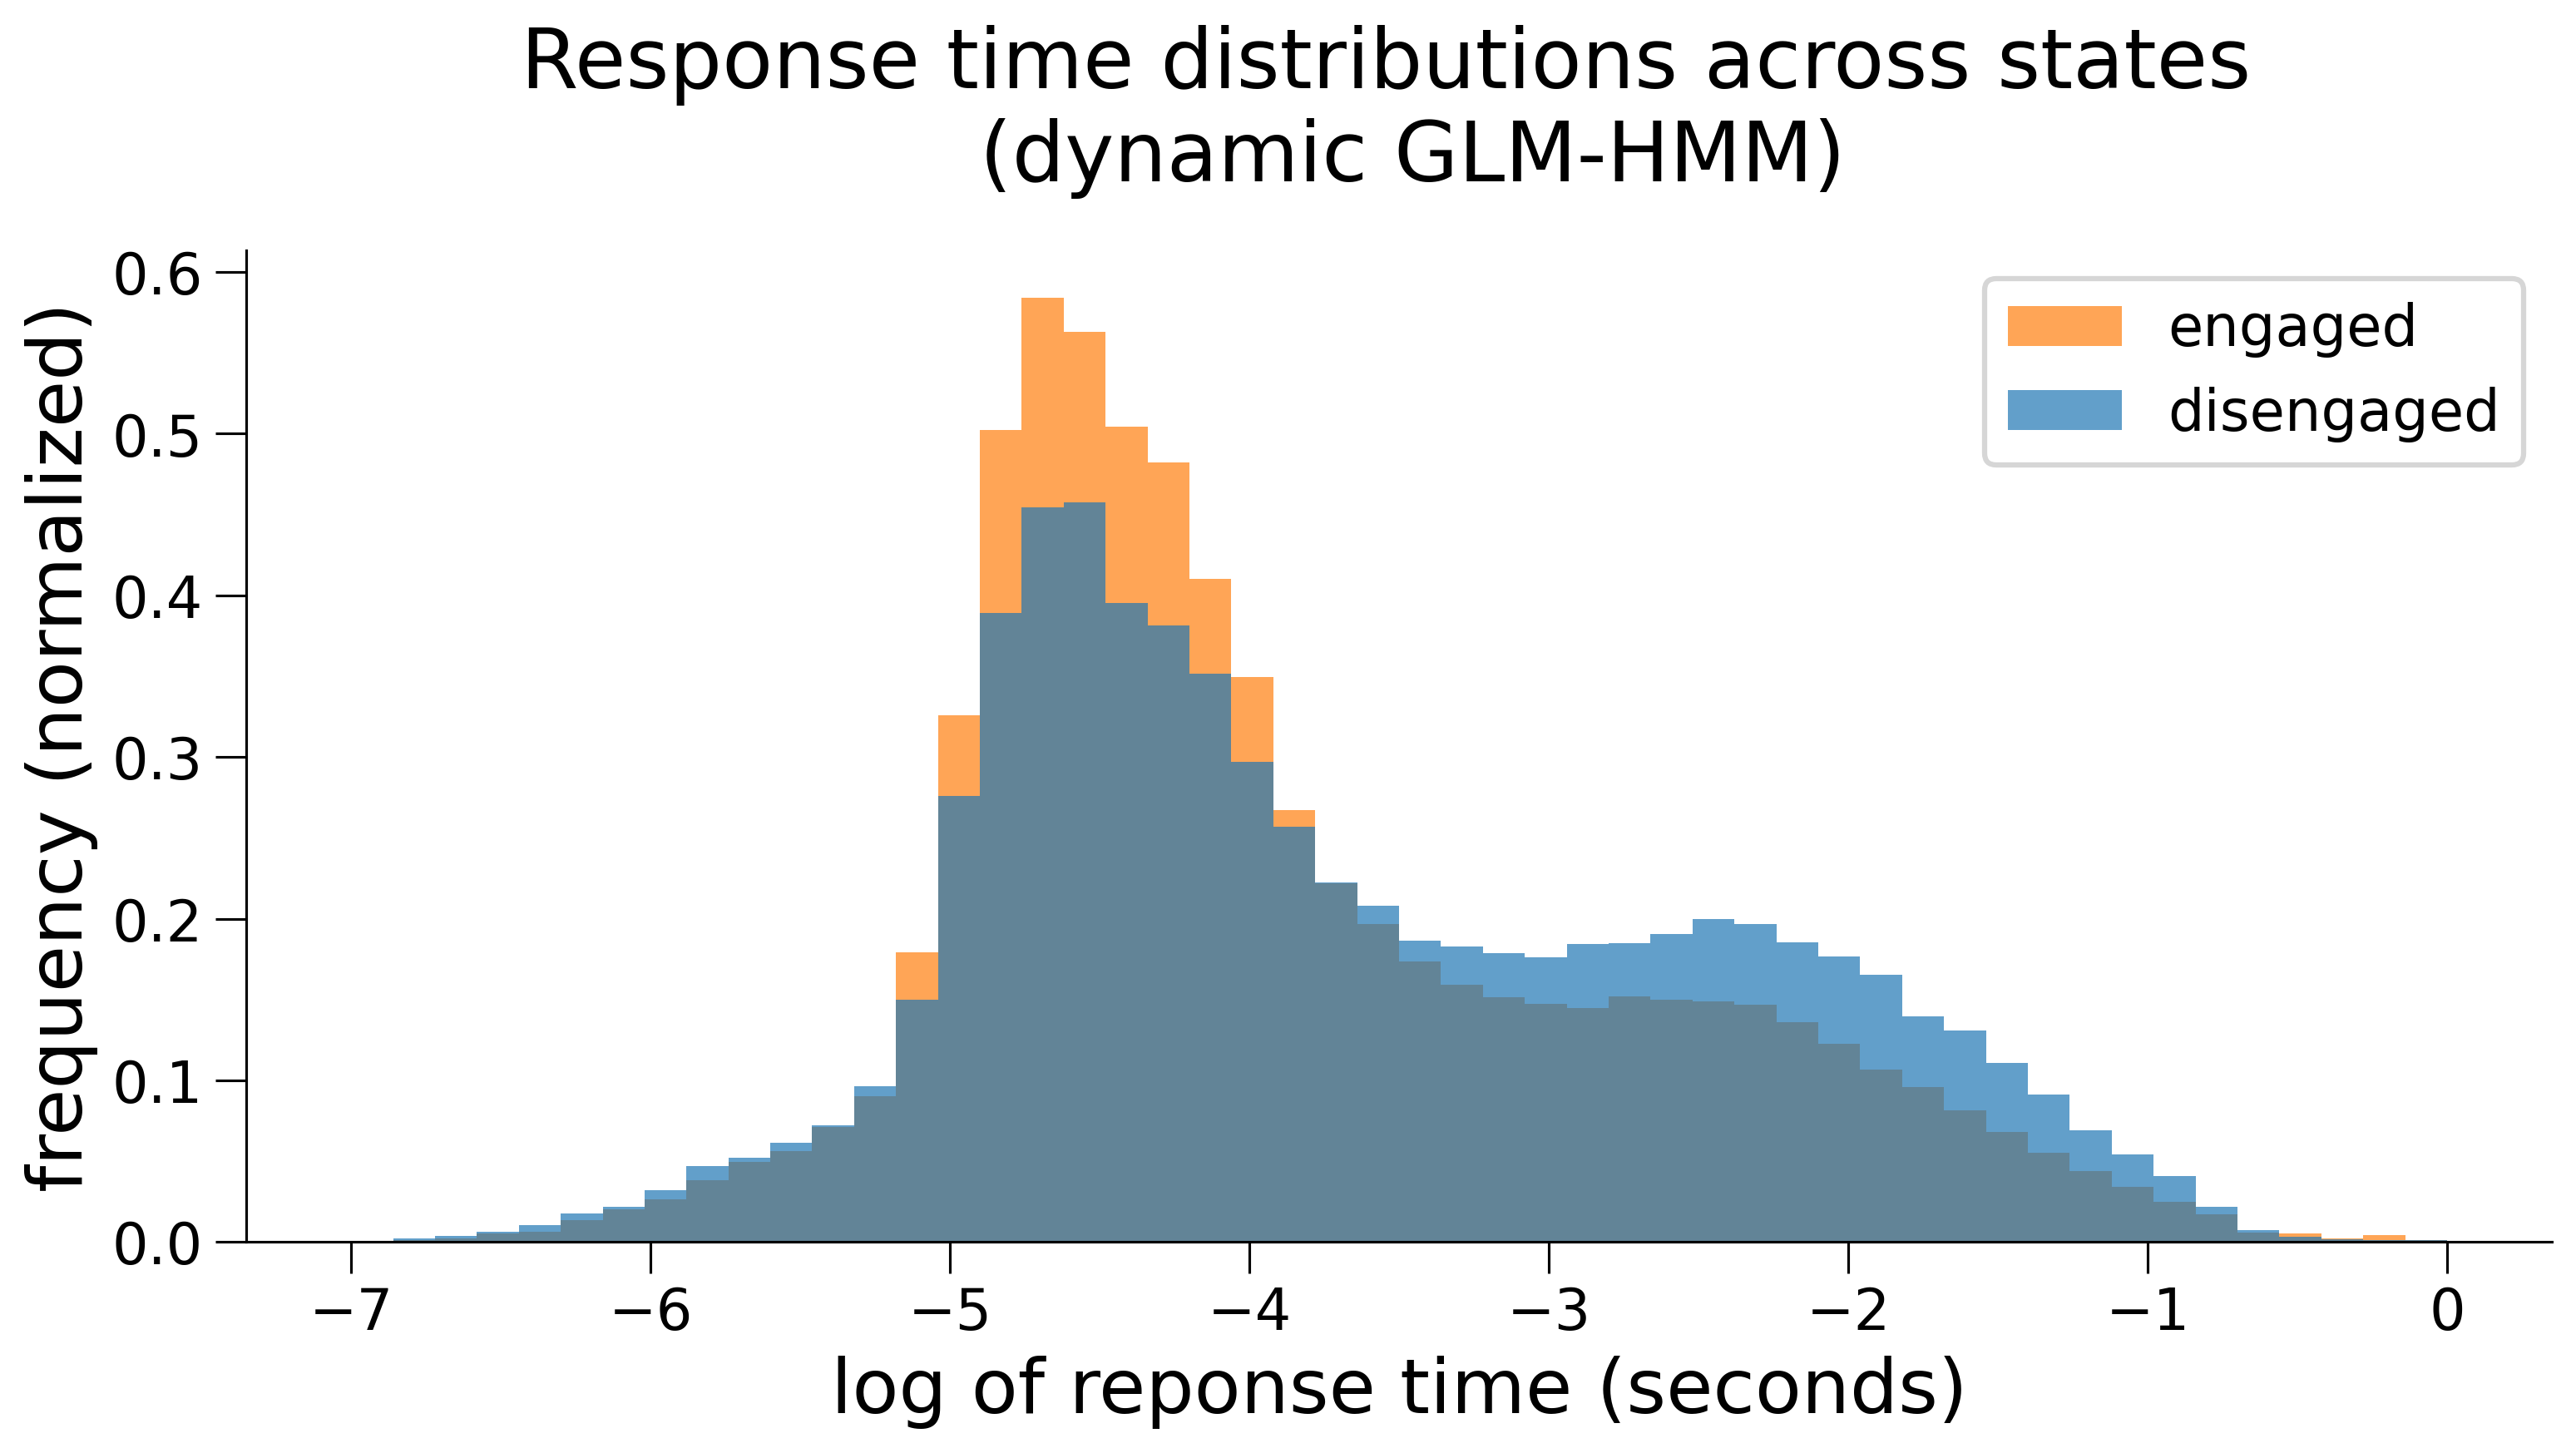

In [126]:
fig, axes = plt.subplots(1, figsize = (10.5,5), dpi=300)
fig.tight_layout()
axes.set_ylabel('frequency (normalized)', size=22)
axes.set_xlabel('log of reponse time (seconds)', size=22)
axes.set_title('Response time distributions across states \n (dynamic GLM-HMM)', size=24, pad=20)
print(np.array(xAll).flatten().shape)
# range=(-4, 4),
axes.hist(np.log(np.array(xAll).flatten()), bins=50, range=(-7, 0), color='tab:orange', alpha=0.7, density=True, label='engaged')
axes.hist(np.log(np.array(yAll).flatten()), bins=50, range=(-7, 0),color='tab:blue', alpha=0.7, density=True, label='disengaged')
axes.legend()
axes.spines[['right', 'top']].set_visible(False)
axes.spines[['left', 'bottom']].set_linewidth(0.75)
axes.xaxis.set_tick_params(width=0.75)
axes.yaxis.set_tick_params(width=0.75)
plt.savefig(f'../figures/Response_time_distributions_engaged_disengaged_dynamic-GLMHMM.pdf', format='pdf', bbox_inches='tight', dpi=300)

In [93]:
print(len(subjectsAll))
print(z)
print(len(idx_significant))
# print((responseTimesStates[0][idx_significant]-responseTimesStates[1][idx_significant])<0)
print(((responseTimesStates[0][idx_significant]-responseTimesStates[1][idx_significant])<0).sum())

32
12
12
10


# Pupil + response analysis on new batch of animals (Churchland)

In [109]:
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [110]:
ibl_data_path = '../data_IBL'
dfIBL_churchland = pd.read_csv(ibl_data_path + '/IBL_processed_new_batch_churchland.csv')
labChosen =  ['churchlandlab']
subjectsAll = []
for lab in labChosen:
    subjects = np.unique(dfIBL_churchland[dfIBL_churchland['lab'] == lab]['subject']).tolist()
    subjectsAll = subjectsAll + subjects
print(f'total subjects {len(subjectsAll)}')
print(subjectsAll)

signedStimulus = True
pTanh = 5
x, y, sessInd, correctSide, responseTimes, pupilMean = get_mouse_design_new_batch(dfIBL_churchland, subject='CSHL024', sessStop=None, signedStimulus=signedStimulus, pTanh=pTanh) 

# print(sessInd)

total subjects 19
['CSHL024', 'CSHL025', 'CSHL045', 'CSHL046', 'CSHL047', 'CSHL049', 'CSHL051', 'CSHL052', 'CSHL053', 'CSHL054', 'CSHL055', 'CSHL058', 'CSHL059', 'CSHL060', 'CSHL062', 'CSHL068', 'CSHL069', 'CSHL072', 'CSHL075']


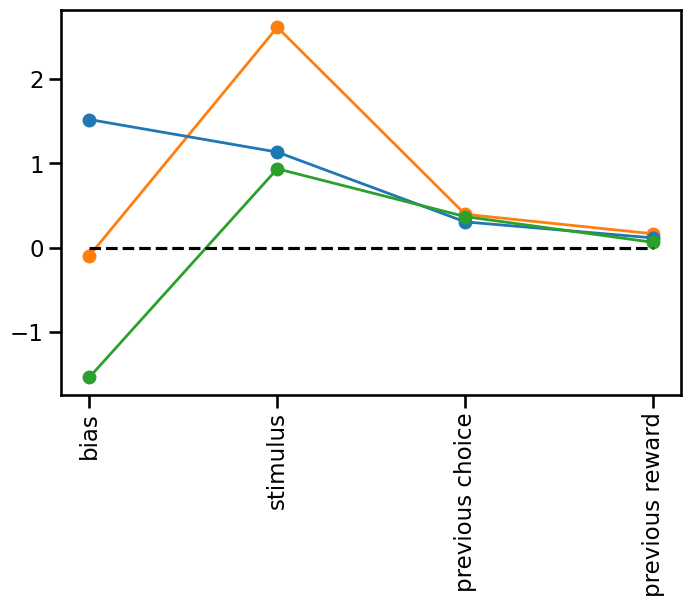

In [111]:
dataInit = np.load(f'../data_IBL/all_animals/Best_allAnimals_standardGLMHMM_{K}-state_pTanh={pTanh}_signedStimulus={signedStimulus}.npz')

fig, axes = plt.subplots(figsize=(8,5))
plot_constant_weights(dataInit['W'][0], axes, labels=myFeatures[0], colors=colorsStates)


In [112]:
dfIBL_churchland = pd.read_csv(ibl_data_path + '/IBL_processed_new_batch_churchland.csv')
# subjectsAll = np.unique(dfIBL_churchland['subject']) 
# ONLY KEEPING SUBJECT WITH AT LEAST 1000 TRIALS
subjectsAll = ['CSHL045','CSHL047','CSHL049','CSHL052','CSHL053','CSHL054','CSHL058','CSHL059','CSHL060','CSHL072','CSHL075']
print(subjectsAll)

# Computing posterior probability of latents across animals (what inferred state the animal is in at each trial)
K = 3
signedStimulus = True
pTanh = 5
D = 4

allGamma = np.empty((len(subjectsAll)), dtype=object)
responseTimesStates = np.zeros((2, len(subjectsAll)))
pupilStates1 = np.zeros((2, len(subjectsAll)))
pupilStates2 = np.zeros((2, len(subjectsAll)))

sortedStateInd = []

significant_idx = []

xAll = []
yAll = []

truepi = np.ones((K)) / K
z = 0
for idx in range(0,len(subjectsAll)):
    subject=subjectsAll[idx]
    print(subject)
    x, y, sessInd, correctSide, responseTimes, pupilMean = get_mouse_design_new_batch(dfIBL_churchland, subject, sessStop=None, signedStimulus=signedStimulus, pTanh=pTanh)
    N = sessInd[-1]
    presentAll = np.ones((N))
    dGLM_HMM = dynamic_glmhmm.dynamic_GLMHMM(N,K,D,2)
    print(N)
    model = np.load(f'../data_IBL/new_batch/New_batch_Churchland_standardGLMHMM_subject-{subject}_{K}-state_pTanh=5_signedStimulus=True.npz')
    standardW, standardP = reshape_parameters_session_to_trials(model['W'], model['P'], sessInd)

    # initW, initP = reshape_parameters_session_to_trials(dataInit['W'][:len(sessInd)], dataInit['P'][:len(sessInd)], sessInd)
    # # fig, axes = plt.subplots(figsize=(8,5))
    # # print(initP[0])
    # plot_constant_weights(initW[0], axes, labels=myFeatures[0], colors=colorsStates)


    # dGLMHMM = dynamic_glmhmm.dynamic_GLMHMM(N,K,D,2)
    # irrelevantSigma = np.ones((K,D))
    # model_type = 'standard'
    # maxiter = 250
    # standardP, standardpi, standardW, _ = dGLMHMM.fit(x, y,  presentAll, initP=initP, initpi=truepi, initW=initW, sigma=irrelevantSigma, sessInd=sessInd, maxIter=maxiter, tol=1e-4, L2penaltyW=1, priorDirP=[10,1], model_type=model_type, fit_init_states=False) 
    # np.savez(f'../data_IBL/new_batch/New_batch_Churchland_standardGLMHMM_subject-{subject}_{K}-state_pTanh={pTanh}_signedStimulus={signedStimulus}', P=standardP[sessInd[:-1]], pi=standardpi, W=standardW[sessInd[:-1]])
    
    # fig, axes = plt.subplots(figsize=(8,5))
    # print(standardP[0])
    # plot_constant_weights(standardW[0], axes, labels=myFeatures[0], colors=colorsStates)

    fitted = np.load(f'../data_IBL/new_batch/New_batch_Churchland_standardGLMHMM_subject-{subject}_{K}-state_pTanh={pTanh}_signedStimulus={signedStimulus}.npz')
    standardW, standardP = reshape_parameters_session_to_trials(fitted['W'], fitted['P'], sessInd)
    
    allGamma[idx] = dGLM_HMM.posterior_likelihood_of_each_state(standardP, truepi, standardW, x, y, presentAll, sessInd, sortedStateInd=None)
    
    print(allGamma[idx].mean(axis=0))
    # # hard assigning the maximum
    # choiceHard = np.argmax(allGamma[idx], axis=1)
    # engagedHard = np.argwhere(choiceHard==0).flatten()
    # disengagedHard = np.argwhere(choiceHard!=0).flatten()

    upper_thr = np.nanquantile(pupilMean, 0.99)
    lower_thr = np.nanquantile(pupilMean, 0.01)
    pupilMean[(pupilMean > upper_thr) | (pupilMean < lower_thr)] = np.nan

    # hard assignment + confidence threshold
    choiceHard = np.argmax(allGamma[idx], axis=1)          # (N,)
    pmax = np.max(allGamma[idx], axis=1)                   # (N,)

    thr = 0.6
    choiceHard_conf = choiceHard.copy()
    choiceHard_conf[pmax < thr] = -1               # unassigned / low-confidence trials

    # indices
    engagedHard = np.where(choiceHard_conf == 0)[0]
    disengagedHard = np.where((choiceHard_conf != 0) & (choiceHard_conf != -1))[0]
    unassigned = np.where(choiceHard_conf == -1)[0]

    pupilStates1[0, idx] = np.nanmedian(pupilMean[engagedHard])
    pupilStates1[1, idx] = np.nanmedian(pupilMean[disengagedHard])

    print(len(engagedHard))
    print(len(disengagedHard))

    if np.isfinite(pupilStates1[0, idx]) and np.isfinite(pupilStates1[1, idx]):
        z+= 1
        # fig, axes = plt.subplots()
        # axes.hist(pupilMean[engagedHard], bins=50, color='tab:orange', alpha=0.5, density=True, label='engaged')
        # axes.hist(pupilMean[disengagedHard], bins=50, color='tab:blue', alpha=0.5, density=True, label='disengaged')
        # axes.legend()

        stat, p = stats.ks_2samp(pupilMean[engagedHard], pupilMean[disengagedHard], alternative='two-sided', mode='auto', nan_policy='omit')
        print(f"stat = {stat:.3f}, p = {p:.3g}")

        stat, p = stats.ranksums(pupilMean[engagedHard], pupilMean[disengagedHard], alternative='two-sided', nan_policy='omit')
        print(f"stat = {stat:.3f}, p = {p:.3g}")

        xAll.append(pupilMean[engagedHard])
        yAll.append(pupilMean[disengagedHard])

        if p < 0.05:
            significant_idx.append(idx)
    
xAll = np.concatenate(xAll, axis=0)
yAll = np.concatenate(yAll, axis=0)



['CSHL045', 'CSHL047', 'CSHL049', 'CSHL052', 'CSHL053', 'CSHL054', 'CSHL058', 'CSHL059', 'CSHL060', 'CSHL072', 'CSHL075']
CSHL045
3950
[0.42048495 0.23272761 0.34678744]
1441
1740
stat = 0.070, p = 0.00103
stat = 3.339, p = 0.000841
CSHL047
1121
[0.85494001 0.13295747 0.01210251]
974
133
stat = 0.498, p = 4.45e-27
stat = -10.867, p = 1.65e-27
CSHL049
2880
[0.49995675 0.19662639 0.30341686]
1310
1187
stat = 0.169, p = 1.22e-15
stat = -8.485, p = 2.15e-17
CSHL052
4393
[0.39764959 0.2862895  0.3160609 ]
1270
1845
stat = 0.036, p = 0.285
stat = -1.455, p = 0.146
CSHL053
2560
[0.76867421 0.01706374 0.21426204]
2006
227
stat = 0.075, p = 0.193
stat = -0.796, p = 0.426
CSHL054
1026
[0.65177035 0.06063587 0.28759377]
687
306
stat = 0.305, p = 2.22e-17
stat = 7.397, p = 1.39e-13
CSHL058
1676
[0.47330648 0.4683043  0.05838922]
759
772
stat = 0.109, p = 0.000235
stat = -4.175, p = 2.97e-05
CSHL059
2994
[0.82142704 0.01018327 0.16838969]
2524
338
stat = 0.064, p = 0.185
stat = -1.237, p = 0.216
CS

In [113]:
print(len(subjectsAll))
print(z)
print(len(significant_idx))
# print((responseTimesStates[0][idx_significant]-responseTimesStates[1][idx_significant])<0)
# print(((responseTimesStates[0][idx_significant]-responseTimesStates[1][idx_significant])<0).sum())

11
11
8


In [114]:
print(pupilStates1[0,significant_idx] - pupilStates1[1,significant_idx] )
print(significant_idx)

[ 0.17780655 -1.99200248 -0.42670117  0.44959966 -0.25667335  0.80863665
  0.16698424  0.13688014]
[0, 1, 2, 5, 6, 8, 9, 10]


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


(14922,)


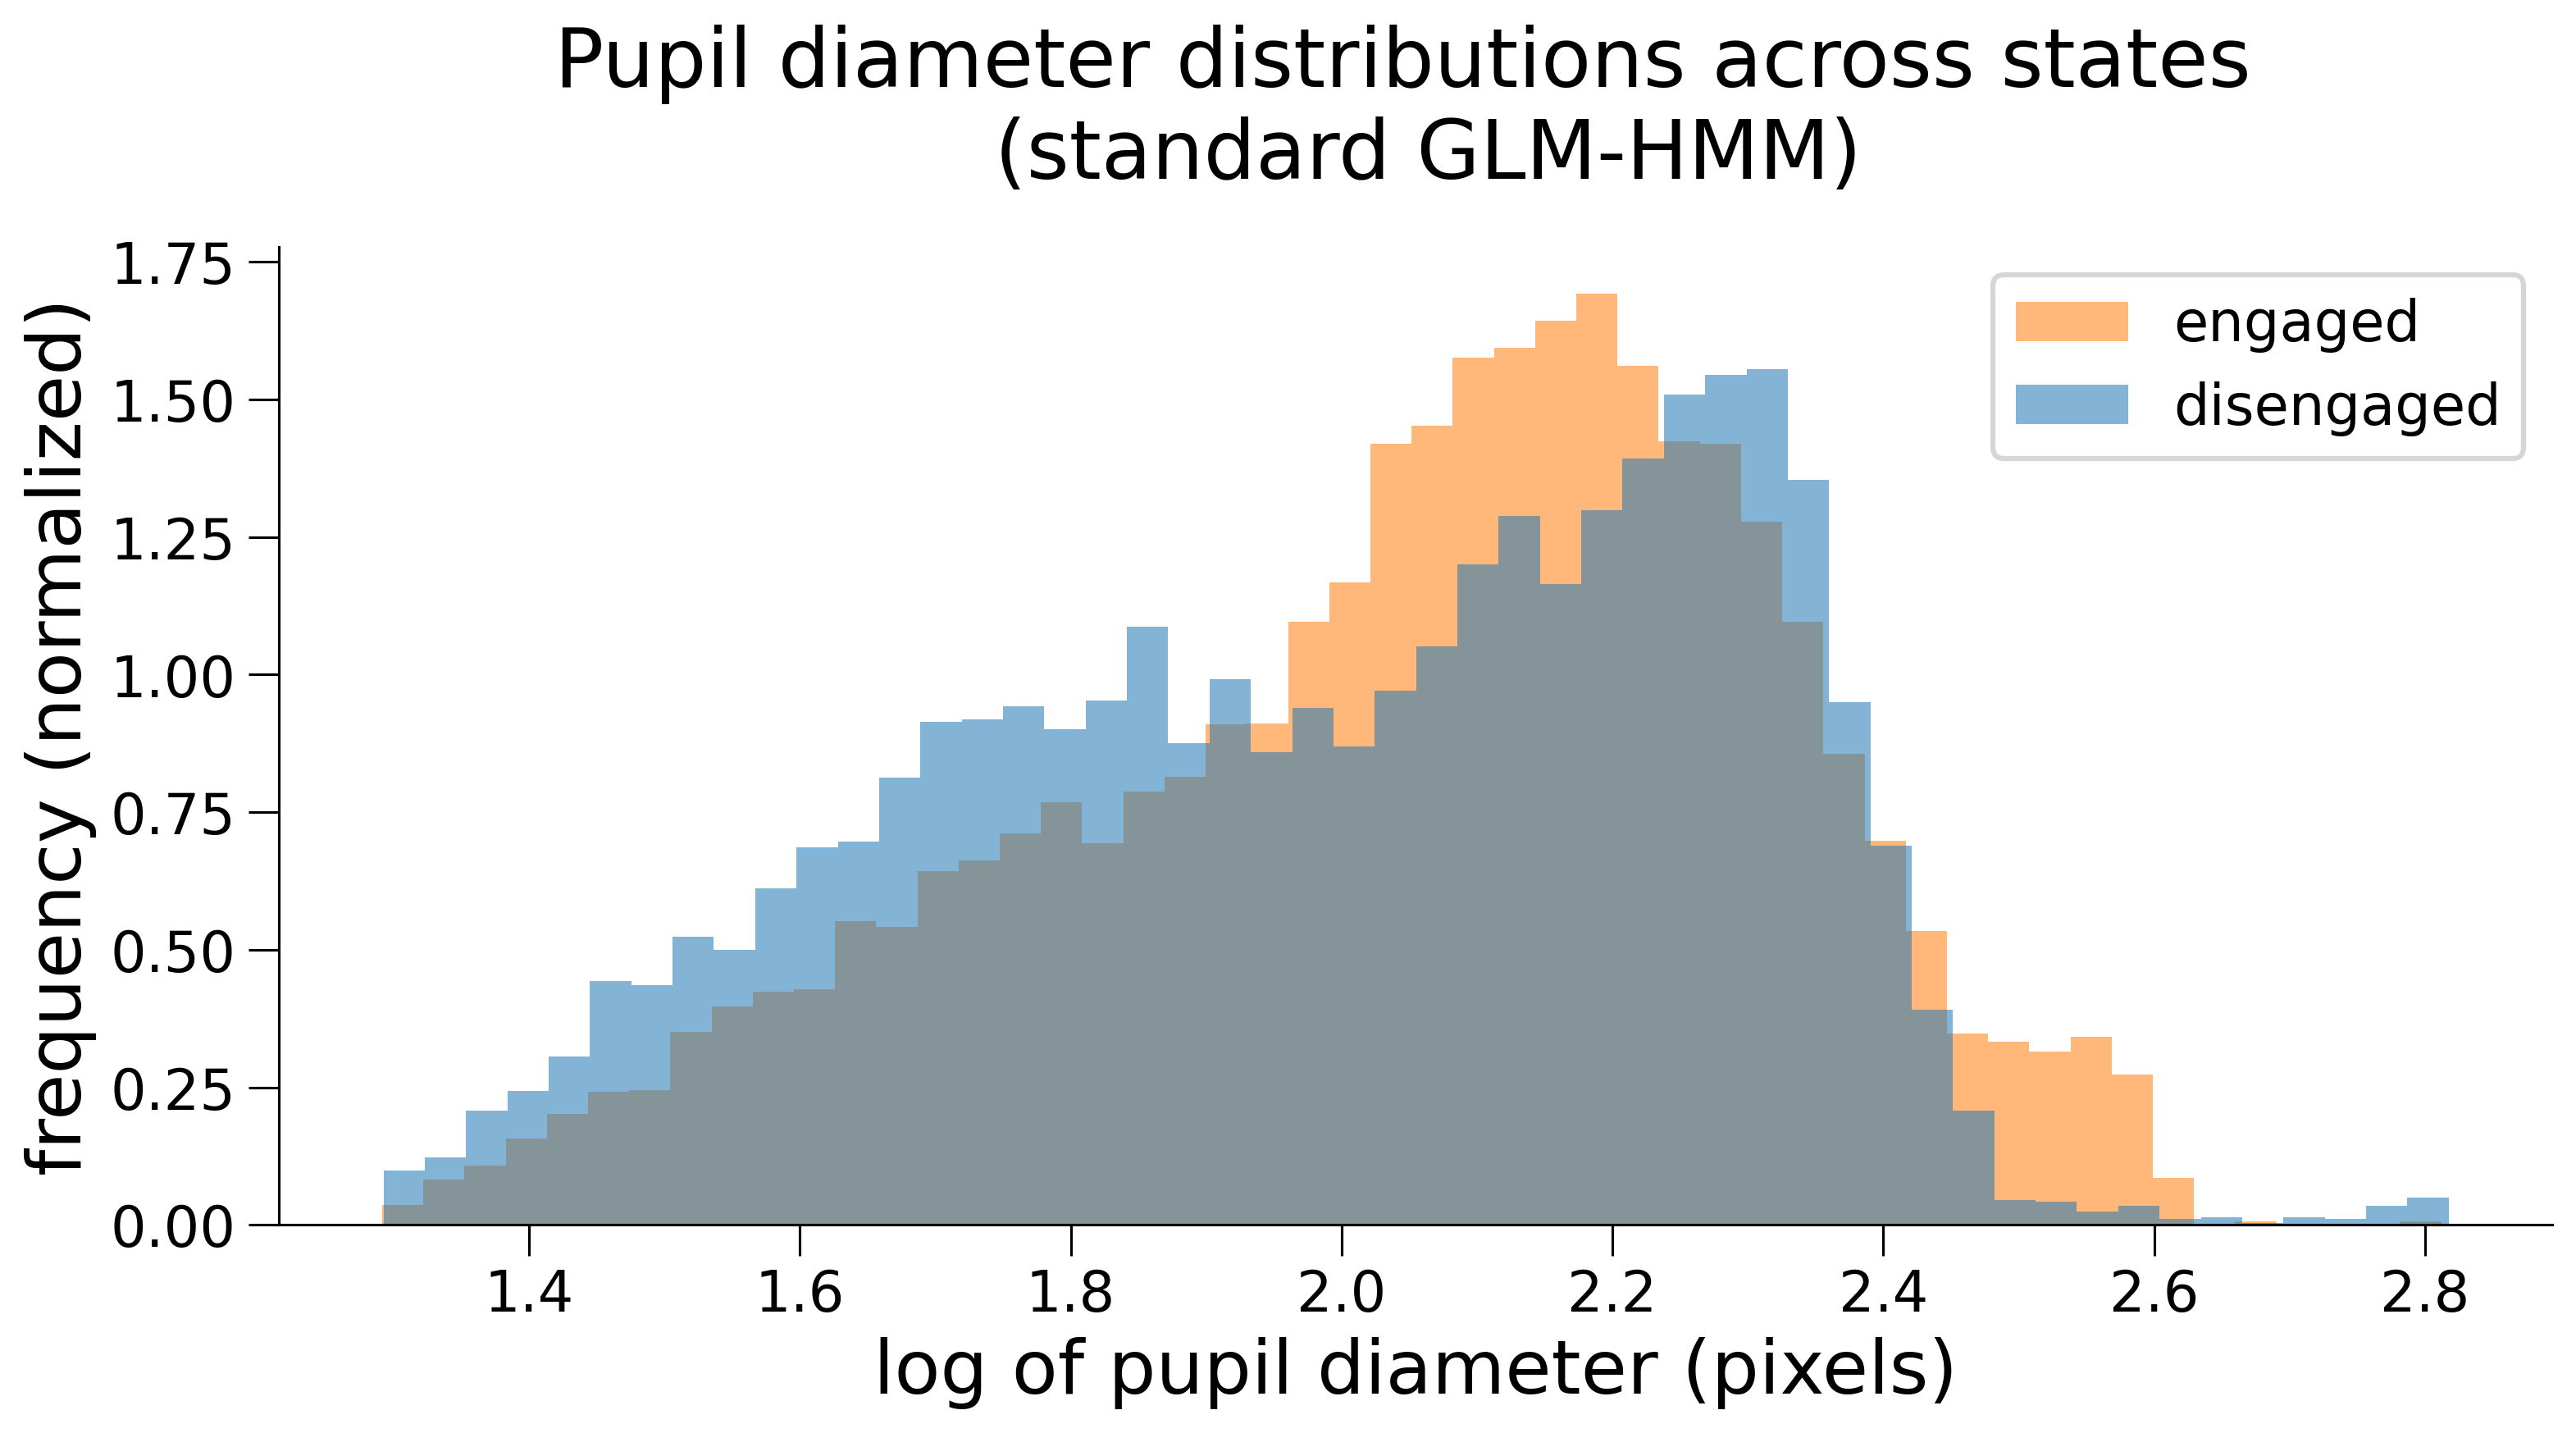

In [117]:
fig, axes = plt.subplots(1, figsize = (10.5,5), dpi=300)
fig.tight_layout()
axes.set_ylabel('frequency (normalized)', size=22)
axes.set_xlabel('log of pupil diameter (pixels)', size=22)
axes.set_title('Pupil diameter distributions across states \n (standard GLM-HMM)', size=24, pad=20)
print(np.array(xAll).flatten().shape)
# range=(-4, 4),
axes.hist(np.log(np.array(xAll).flatten()), bins=50,  color='tab:orange', alpha=0.55, density=True, label='engaged')
axes.hist(np.log(np.array(yAll).flatten()), bins=50, color='tab:blue', alpha=0.55, density=True, label='disengaged')
axes.legend()
axes.spines[['right', 'top']].set_visible(False)
axes.spines[['left', 'bottom']].set_linewidth(0.75)
axes.xaxis.set_tick_params(width=0.75)
axes.yaxis.set_tick_params(width=0.75)
plt.savefig(f'../figures/Pupil_diameter_distributions_engaged_disengaged_dynamic-GLMHMM.eps', format='eps', bbox_inches='tight', dpi=300)